# Nonlinear Heat Conduction Problem with hyper-reduction, reduction and full order simulation

![Problem Schematic](problem_schematics.png)

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.fom.fem_utils import load_domain
from skrom.utils.visualization.plot_utils import *
import skrom.problem_classes.static.master_class as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

# SKROM ROM (Reduced Order Modeling) core classes
from skrom.rom.linear_form_rom import LinearFormROM
from skrom.rom.ecsw.hyperreduce import hyperreduce
from problem_def import ProblemNonLinear
# Problem-specific linear forms
from linear_forms import R

### Plot Properties


## Full Order Simulation


In [3]:
# Control flag for expensive simulation generation

generate = False

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots = 32)
    sim.run_simulation()


### Load Simulation Data

In [4]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/examples/computational_mechanics/static/non_linear/problem_1_h/ROM_data


## Data Generation

### Generate Training Solution Dataset



In [5]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

64


### Mean Subtraction

In [6]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

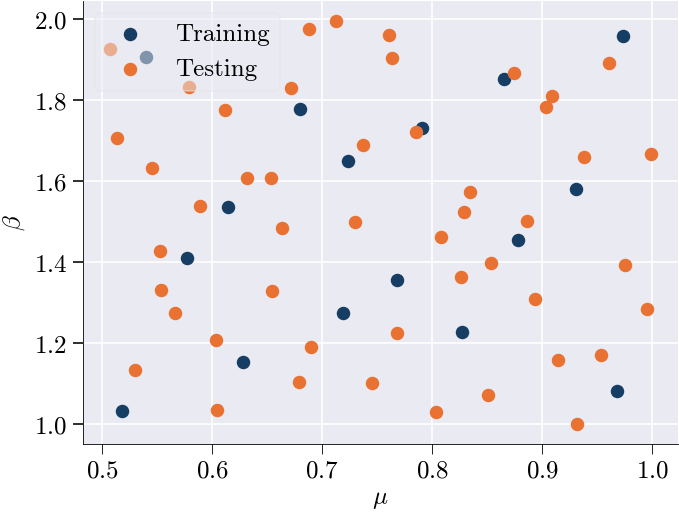

In [7]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 8


Text(0.5, 0, 'POD modes ($k$)')

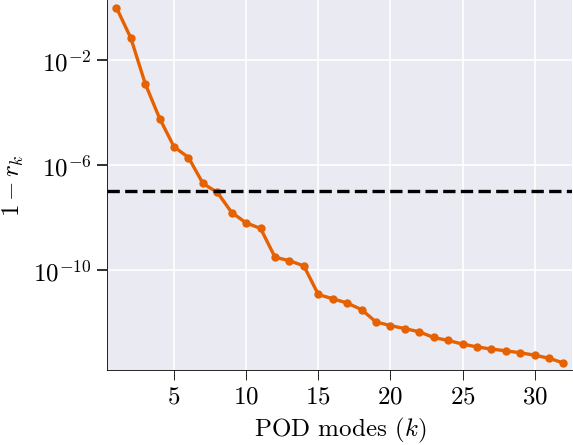

In [8]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-7,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors

n_sel = 6

# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation


In [20]:
# Initialize the reduced-order model (ROM) simulation
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
#   n_sel : number of basis vectors (modes) to retain in the ROM
rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/examples/computational_mechanics/static/non_linear/problem_1_h/ROM_data


In [21]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
generate = True
if generate:
    rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/64 params=[0.60441857 1.03585147]
1 0.003449750995855179
2 3.337767345082339e-06
Snap 2/64 params=[0.90849612 1.81201197]
1 0.0032229832261260727
2 3.697805342916625e-06
Snap 3/64 params=[0.80825427 1.463416  ]
1 0.0020641235153265863
2 1.4208524331785759e-06
Snap 4/64 params=[0.73733329 1.68920741]
1 0.005095770979118509
2 9.372613996018295e-06
Snap 5/64 params=[0.6549118  1.33006367]
1 0.0026329626141223797
2 2.2692438616450473e-06
Snap 6/64 params=[0.83398938 1.57303659]
1 0.001586757908689478
2 8.427675690285241e-07
Snap 7/64 params=[0.95304304 1.17164498]
1 0.008698005260654744
2 2.3243487626103e-05
Snap 8/64 params=[0.50712202 1.92671818]
1 0.024646411953344945
2 0.00026923005093367256
Snap 9/64 params=[0.55290247 1.42934462]
1 0.008965846696593104
2 2.263953505327735e-05
Snap 10/64 params=[0.99858256 1.66851882]
1 0.009442341910414842
2 2.69947816868687e-05
Snap 11/64 params=[0.85098126 1.07187502]
1 0.005692028734740976
2 1.0303519312168452e-05
Snap 12/64 params=[0.67166

In [22]:
#Assign values for the statistics
NLS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 1.0067e-07
Relative L2 Error:        1.4259e-09
L∞ Error:                 2.2735e-09
Relative L∞ Error:        4.2661e-09
RMSE:                     1.8793e-10
MAE:                      6.4495e-11

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             1.0157e-12
95th Percentile Error:    1.6946e-10

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 6.9030e-10
Max Rel L2 Error over time/parameter: 7.2410e-09
Min Rel L2 Error over time/parameter: 1.0193e-10
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

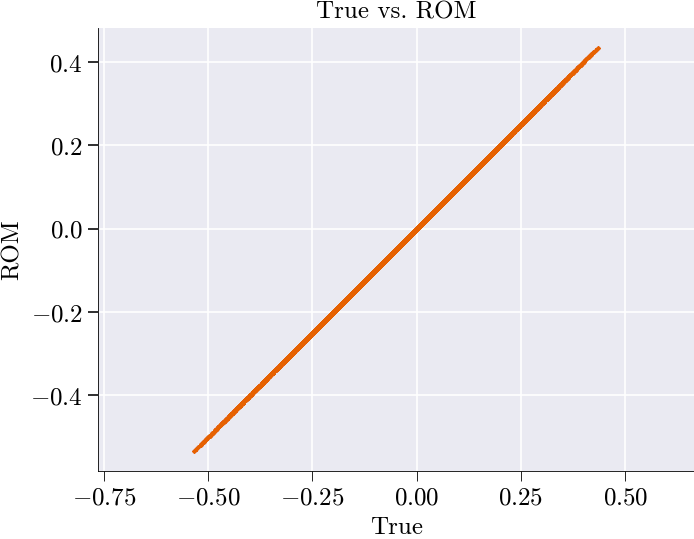

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


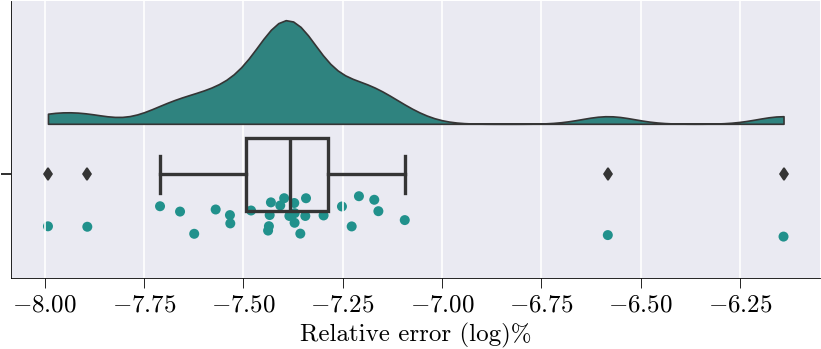

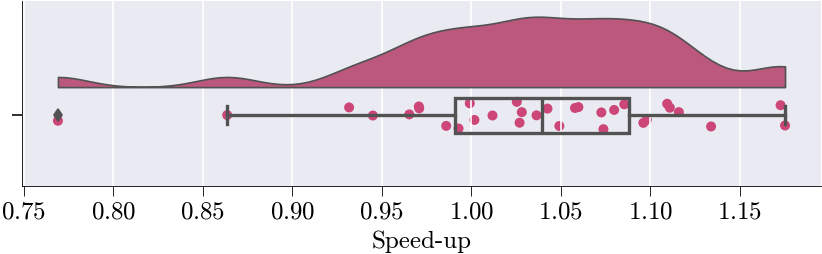

In [23]:
# --- Standard ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

# Produce a text-based report summarizing these error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the standard ROM
plot_rom_error_diagnostics_flat(
    NLS_test,               # full-order (true) solution snapshots
    NLS_rom,                # ROM-generated solution snapshots
    ROM_relative_error,     # precomputed relative error of the ROM
    ROM_speed_up,           # precomputed speed-up factor of the ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix          # the matrix of error metrics just computed
)


## Hyper ROM Simulation


### Mesh Sampling


In [10]:
prob = ProblemNonLinear()
sim_data['dirichlet_dofs'] = prob.domain()['dirichlet_dofs']
free_dofs = sim_data['basis'].item().complement_dofs(sim_data['dirichlet_dofs'])
prob.mesh = sim_data['mesh'].item()  
# Get the finite element basis object for ROM construction
# This contains the spatial discretization information and basis functions
basis = sim_data['basis'].item()


In [11]:
# Create the ROM residual linear form object
# This represents the linear form R(u,v) in the weak formulation of the PDE
Residual = LinearFormROM(R,                    # Linear form function from problem definition
                         basis,                 # Finite element basis functions
                         V_sel,                 # Selected POD modes (reduced basis)
                         free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

# Extract parameter values corresponding to training snapshots
# Uses the boolean mask to get only the parameter combinations used for training
training_params = param_list[train_mask]

In [12]:
# Collect residual evaluations for all training snapshots
# This creates the dataset needed for hyperreduction of nonlinear ROM terms
q_mus = collect_residuals(
    NLS_train_ms,         # Mean-centered training snapshots
    NLS_train_mean,       # Mean temperature field
    V_sel,                # Selected POD basis modes
    reconstruct_solution, # Solution reconstruction function
    Residual,             # ROM residual operator
    training_params,
    prob.assemble_kwargs,
)

# Display the shape of collected residuals for verification
# Shape should be: (n_training_snapshots * SVD components, n_residual_evaluation_points)
print(q_mus.shape)

#Output should be 16(for training snapshots) * 5(SVD components selected) = 80

(192, 2160)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 40.31833794775401


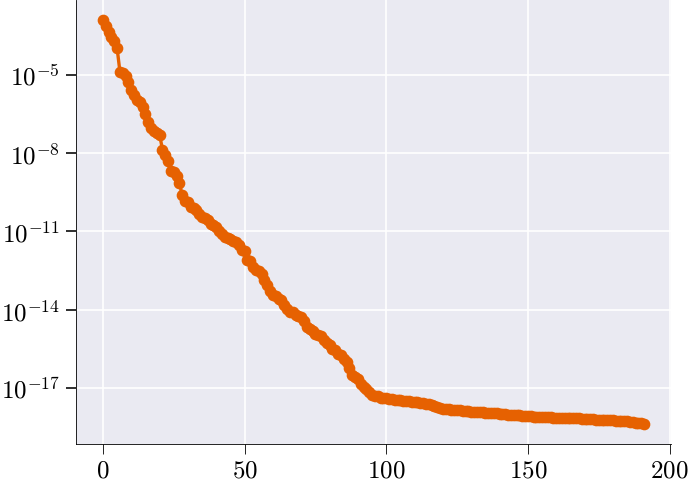

In [13]:
print("Performing SVD...")
# Performs Singular Value Decomposition on q_mus matrix
# Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

# Plots singular values on a logarithmic y-scale to visualize their decay
# This helps identify the effective rank/dimensionality of the matrix
plt.semilogy(s, 'o-')

# Takes the first 20 right singular vectors (rows of Vh)
# This creates a reduced basis capturing the most significant modes
V_q_eff = Vh[:100]

# Computes a weighted combination of the basis vectors
# Each basis vector is weighted equally (multiplied by 1)
# This essentially sums all 20 basis vectors
d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

# Outputs the L2 norm of the resulting vector
# This gives a sense of the magnitude of the combined basis representation
print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [14]:
# Solve the non-negative least squares (NNLS) problem using hyperreduce
#   V_q_eff   : effective basis matrix
#   verbosity : level of log output (2 = detailed)
#   const_tol : tolerance for column selection
#   zero_tol  : tolerance to treat values as zero
#   plot      : disable plotting
x_nnls_m, err = hyperreduce(
    V_q_eff,
    verbosity=2,
    const_tol=1e-8,
    zero_tol=1e-8,
    plot=False
)

# Compute and print the relative NNLS reconstruction error:
#   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 100 2160 0 1.116468487250198e+01 4.031833794775401e+01
1 1 100 2160 1 1.113200229323044e+01 4.018680840119323e+01
2 2 100 2160 2 1.114526698854469e+01 4.005055093792596e+01
3 3 100 2160 3 1.107082076912621e+01 3.945722604397216e+01
4 4 100 2160 4 1.182165289296159e+01 3.914887160661148e+01
5 5 100 2160 5 1.172908544605321e+01 3.862472613325785e+01
6 6 100 2160 6 1.185073373379892e+01 3.844248756055155e+01
7 7 100 2160 7 1.164791334486404e+01 3.824535784926690e+01
8 8 100 2160 8 1.141774231093492e+01 3.805470251422634e+01
9 9 100 2160 9 1.221540470290195e+01 3.741401585939385e+01
10 10 100 2160 10 1.189325130901838e+01 3.731652456331529e+01
11 11 100 2160 11 1.028900080973375e+01 3.661048897749361e+01
12 12 100 2160 12 1.080926378410098e+01 3.635926953802290e+01
13 13 100 2160 13 1.135999186625556e+01 3.592629705267585e+01
14 14 100 2160 14 1.136958336409661e+01 3.584766278644098e+01
15 15 100 2160 15 1.121702406982100e+01

#### Plot Reduced Meshes with weights

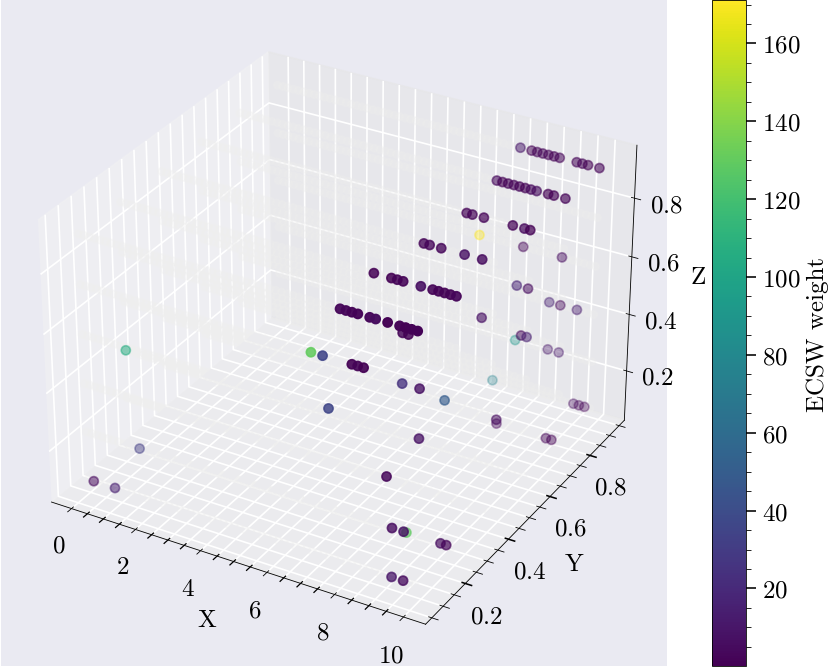

In [15]:
fig, ax = plot_ecsw_weights_3d(prob.mesh, x_nnls_m, projection='3d')

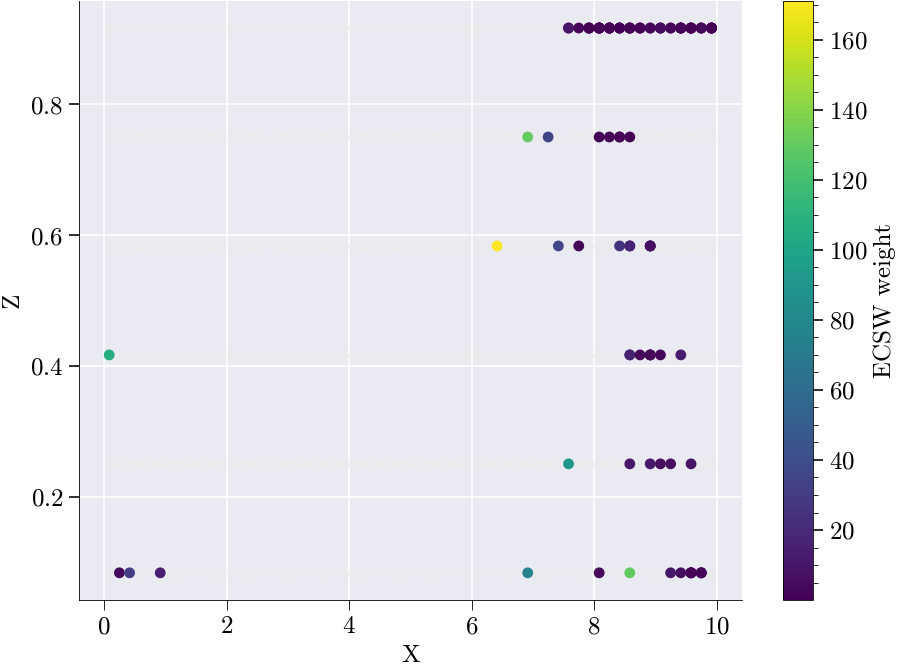

In [16]:
fig, ax = plot_ecsw_weights_3d(prob.mesh, x_nnls_m, projection='projected', plane='xz')

### Run HyperROM simulation


In [17]:
# Run the hyper-reduced ROM simulation using the NNLS weights
#   x_nnls_m : array of non-negative least squares coefficients,
#              used here to weight the reduced basis contributions
#rom will contain the hyper_rom solution as an attribute
# rom.run_hyper_rom_simulation(np.random.rand(640));
rom.run_hyper_rom_simulation_ecsw(x_nnls_m)

Snap 1/64 params=[0.60441857 1.03585147]
1 0.06185069483964993
2 6.765896686237866e-05
Snap 2/64 params=[0.90849612 1.81201197]
1 0.003703581836029681
2 5.225529967247482e-06
Snap 3/64 params=[0.80825427 1.463416  ]
1 0.002375544663331704
2 2.001546037672948e-06
Snap 4/64 params=[0.73733329 1.68920741]
1 0.005895286138995698
2 1.3202656020949157e-05
Snap 5/64 params=[0.6549118  1.33006367]
1 0.003054935508243308
2 3.1768722561982834e-06
Snap 6/64 params=[0.83398938 1.57303659]
1 0.0018299431146988133
2 1.1856398972031055e-06
Snap 7/64 params=[0.95304304 1.17164498]
1 0.00983522685006886
2 3.3155589978006536e-05
Snap 8/64 params=[0.50712202 1.92671818]
1 0.02865917323198358
2 0.0003861450563467444
Snap 9/64 params=[0.55290247 1.42934462]
1 0.010547738528803292
2 3.114615382593834e-05
Snap 10/64 params=[0.99858256 1.66851882]
1 0.010925026856615441
2 3.780741881792162e-05
Snap 11/64 params=[0.85098126 1.07187502]
1 0.006410226553373689
2 1.4735791827001234e-05
Snap 12/64 params=[0.671660

([0.4720293947955079,
  0.46762994492454985,
  0.47052033759833345,
  0.46297743674036146,
  0.46705701166658226,
  0.46933494372505935,
  0.4791363870152472,
  0.44125296365378724,
  0.45844048976256896,
  0.47269356484175534,
  0.4787316978497037,
  0.45631620479096013,
  0.4718463346192136,
  0.4585062851381892,
  0.47581016305163076,
  0.4580463536267539,
  0.4635861087269373,
  0.4723035962288935,
  0.4738372864820079,
  0.45519054047453267,
  0.47335119062125547,
  0.4654078789417347,
  0.4763526349328548,
  0.4522938754195903,
  0.46532219431398436,
  0.4680122461000064,
  0.4730127181343591,
  0.45900929920516487,
  0.46668261508301156,
  0.46447429543605656,
  0.4810663838519246,
  0.4536829271743049],
 [4.432046056640776,
  5.818241661775231,
  5.947603053105989,
  6.437612969541608,
  5.981441241634379,
  6.428833299366393,
  5.4426435159104285,
  5.39309149787866,
  6.170035186872065,
  6.485041798428136,
  6.61184508798642,
  6.7650668000604535,
  6.763006725444251,
  4.90

In [18]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 3.2931e-01
Relative L2 Error:        4.6645e-03
L∞ Error:                 1.7328e-03
Relative L∞ Error:        3.2516e-03
RMSE:                     6.1476e-04
MAE:                      4.4407e-04

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       0.9980

Error Distribution:
Median Error:             -1.0844e-04
95th Percentile Error:    1.2648e-03

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 4.6637e-03
Max Rel L2 Error over time/parameter: 4.8107e-03
Min Rel L2 Error over time/parameter: 4.4125e-03
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

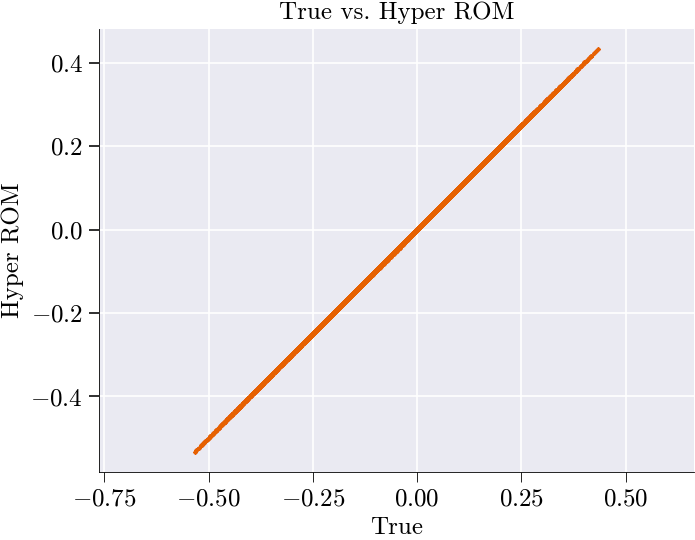

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


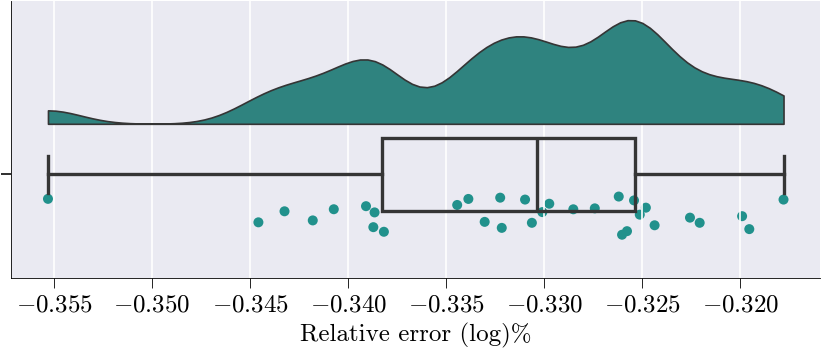

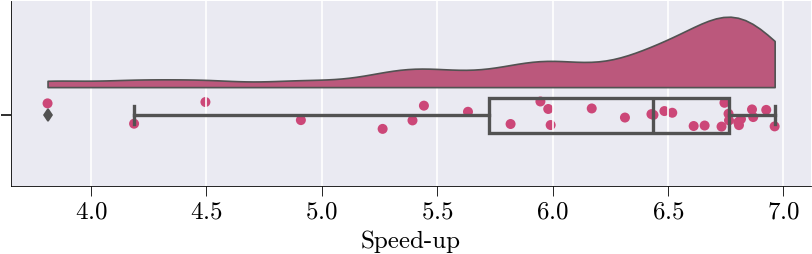

In [19]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)

